In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
GOOGLE_COLAB = True
path = ""
if GOOGLE_COLAB:
    from google.colab import drive, files
    drive.mount('/content/drive/')
    path = "/content/drive/My Drive/ML AI/"

dataset = path + "diabetes_database.csv"
df = pd.read_csv(dataset)

print(f"\nShape: {df.shape}")
print(f"Non-Diabetic: {(df['Outcome']==0).sum()}")
print(f"Diabetic: {(df['Outcome']==1).sum()}")

Mounted at /content/drive/

Shape: (768, 9)
Non-Diabetic: 500
Diabetic: 268


In [ ]:
# Splitting and scaling
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {X_train.shape[0]}")
print(f"Testing: {X_test.shape[0]}")

# (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training: 614
Testing: 154


In [ ]:
# Training classifier on all features
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("Metrics:")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"AUC:       {auc:.4f} ({auc*100:.2f}%)")

Metrics:
Accuracy:  0.7143 (71.43%)
Precision: 0.6087 (60.87%)
Recall:    0.5185 (51.85%)
F1-Score:  0.5600 (56.00%)
AUC:       0.8230 (82.30%)


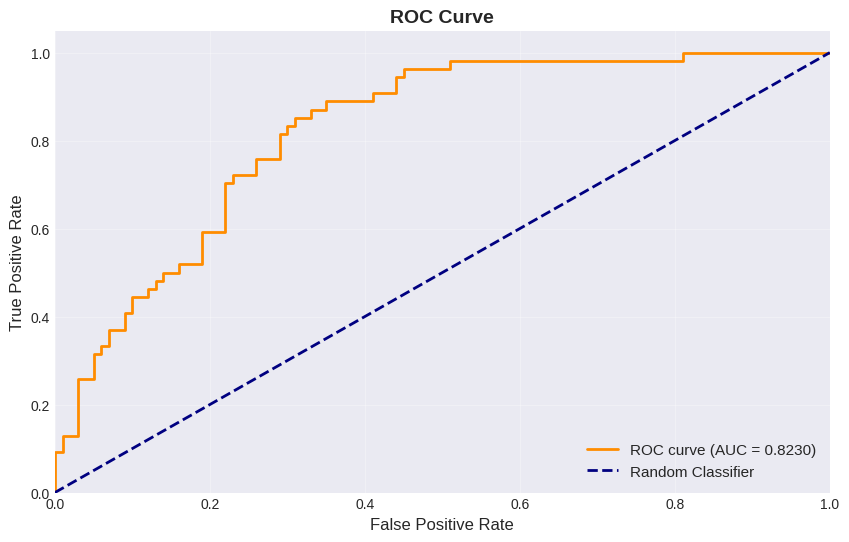

In [ ]:
# ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

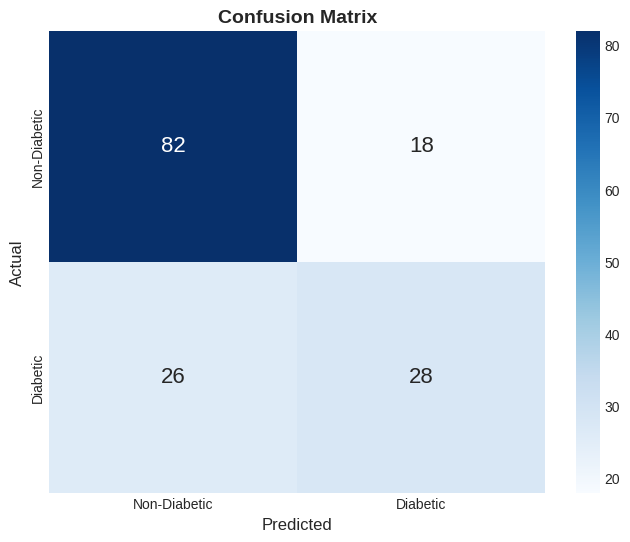

True Negatives(TN):  82 (Correctly predicted non-diabetic.)
False Positives(FP): 18 (Incorrectly predicted diabetic.)
False Negatives(FN): 26 (Incorrectly predicted non-diabetic.)
True Positives(TP):  28 (Correctly predicted diabetic.)


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            annot_kws={"size": 16})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.show()

print(f"True Negatives(TN):  {cm[0,0]} (Correctly predicted non-diabetic.)")
print(f"False Positives(FP): {cm[0,1]} (Incorrectly predicted diabetic.)")
print(f"False Negatives(FN): {cm[1,0]} (Incorrectly predicted non-diabetic.)")
print(f"True Positives(TP):  {cm[1,1]} (Correctly predicted diabetic.)")


Importance is based on coefficient magnitude:
                 Feature  Coefficient  Abs_Coefficient
                 Glucose     1.144151         1.144151
                     BMI     0.713893         0.713893
             Pregnancies     0.373178         0.373178
DiabetesPedigreeFunction     0.255527         0.255527
           BloodPressure    -0.197637         0.197637
                     Age     0.184179         0.184179
                 Insulin    -0.127308         0.127308
           SkinThickness     0.066535         0.066535


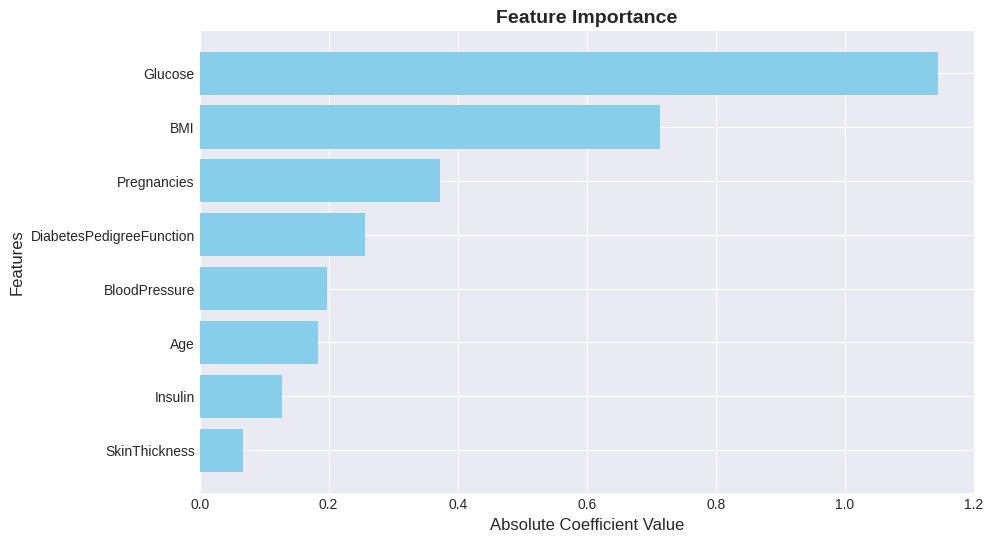

In [ ]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Abs_Coefficient': np.abs(model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("\nImportance is based on coefficient magnitude:")
print(feature_importance[['Feature', 'Coefficient', 'Abs_Coefficient']].to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Abs_Coefficient'],
         color='skyblue')
plt.xlabel('Absolute Coefficient Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

Variance by PC1: 0.2607 (26.07%)
Variance by PC2: 0.2182 (21.82%)
Total variance explained: 0.4789 (47.89%)

PCA Component Loadings:
                               PC1       PC2
Pregnancies               0.057642  0.597753
Glucose                   0.384083  0.248030
BloodPressure             0.307684  0.205026
SkinThickness             0.458675 -0.304096
Insulin                   0.489300 -0.178050
BMI                       0.439318 -0.053344
DiabetesPedigreeFunction  0.300789 -0.115532
Age                       0.145663  0.631480


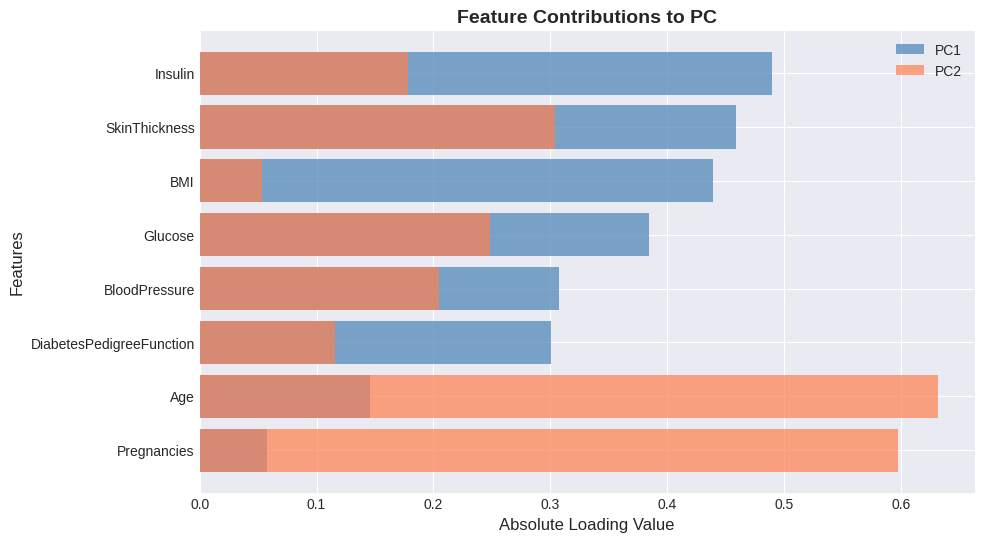

In [ ]:
# PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Variance by PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"Variance by PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")

print("\nPCA Component Loadings:")
pca_components = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)
print(pca_components)

plt.figure(figsize=(10, 6))
pca_components_plot = pca_components.abs().sort_values('PC1', ascending=True)
plt.barh(pca_components_plot.index, pca_components_plot['PC1'],
         alpha=0.7, label='PC1', color='steelblue')
plt.barh(pca_components_plot.index, pca_components_plot['PC2'],
         alpha=0.7, label='PC2', color='coral')
plt.xlabel('Absolute Loading Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Contributions to PC', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

/tmp/ipython-input-155699261.py:47: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_pca[idx, 0], X_test_pca[idx, 1],


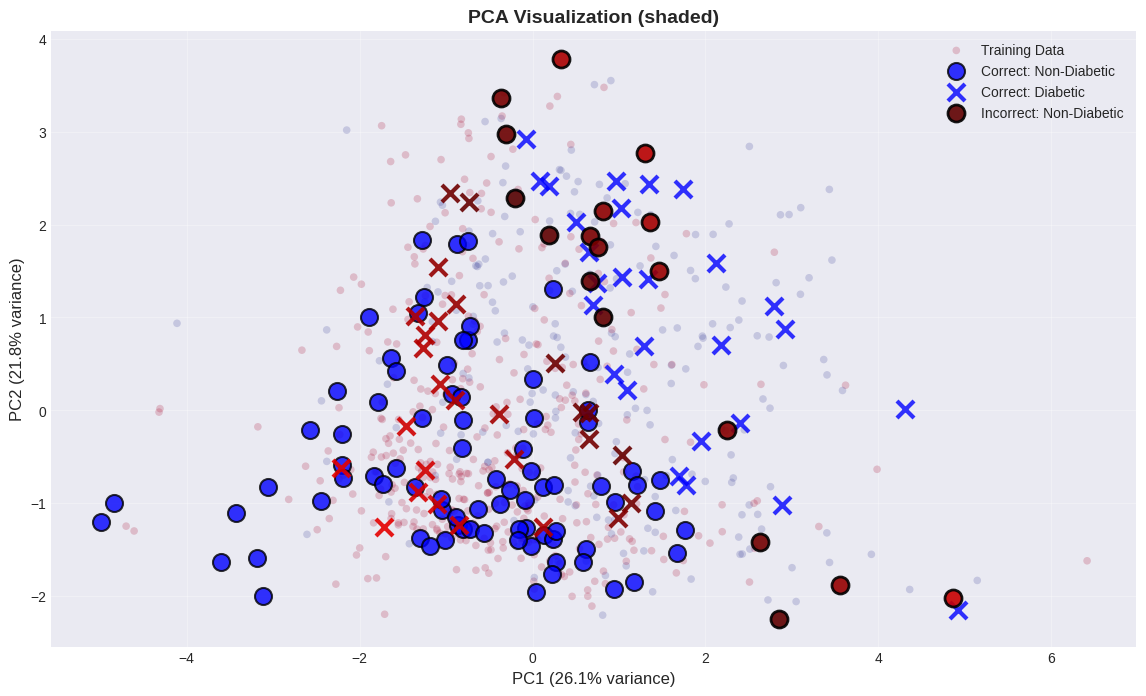

Correctly classified:   109 / 154
Incorrectly classified: 45 / 154
Accuracy on PCA data:   0.7078

Darker red = Higher confidence (but wrong)
Lighter red  = Lower confidence (closer to boundary)


In [ ]:
# Training classifier on PCA data
model_pca = LogisticRegression(max_iter=1000, random_state=42)
model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)
y_pred_proba_pca = model_pca.predict_proba(X_test_pca)[:, 1]

correct_mask = (y_pred_pca == y_test)
incorrect_mask = ~correct_mask

plt.figure(figsize=(14, 8))

scatter_train = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                           c=y_train, cmap='RdYlBu',
                           alpha=0.2, s=30, edgecolors='none',
                           label='Training Data')

# Class 0 (Non-Diabetic) - circles, blue
correct_class0 = correct_mask & (y_test == 0)
plt.scatter(X_test_pca[correct_class0, 0], X_test_pca[correct_class0, 1],
           c='blue', marker='o', s=150, edgecolors='black', linewidth=1.5,
           alpha=0.8, label='Correct: Non-Diabetic')

# Class 1 (Diabetic) - crosses, blue
correct_class1 = correct_mask & (y_test == 1)
plt.scatter(X_test_pca[correct_class1, 0], X_test_pca[correct_class1, 1],
           c='blue', marker='x', s=150, linewidth=3,
           alpha=0.8, label='Correct: Diabetic')

incorrect_indices = np.where(incorrect_mask)[0]

for idx in incorrect_indices:
    prob = y_pred_proba_pca[idx]
    actual = y_test.iloc[idx]

    # If prob close to 0.5, less confident (lighter red) and if prob close to 0 or 1, more confident (darker red)
    confidence = abs(prob - 0.5) * 2
    red_intensity = 0.3 + (0.7 * confidence)

    if actual == 0:  # True class 0, predicted 1
        marker = 'o'
        label = 'Incorrect: Non-Diabetic' if idx == incorrect_indices[0] else ''
    else:
        marker = 'x'
        label = 'Incorrect: Diabetic' if idx == incorrect_indices[0] else ''

    plt.scatter(X_test_pca[idx, 0], X_test_pca[idx, 1],
               c=[(red_intensity, 0, 0)], marker=marker, s=150,
               edgecolors='black', linewidth=2 if marker=='o' else 3,
               alpha=0.9, label=label)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('PCA Visualization (shaded)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Correctly classified:   {correct_mask.sum()} / {len(y_test)}")
print(f"Incorrectly classified: {incorrect_mask.sum()} / {len(y_test)}")
print(f"Accuracy on PCA data:   {accuracy_score(y_test, y_pred_pca):.4f}")
print("\nDarker red = Higher confidence (but wrong)")
print("Lighter red  = Lower confidence (closer to boundary)")

In [ ]:
accuracy_pca = accuracy_score(y_test, y_pred_pca)
precision_pca = precision_score(y_test, y_pred_pca)
recall_pca = recall_score(y_test, y_pred_pca)
f1_pca = f1_score(y_test, y_pred_pca)
auc_pca = roc_auc_score(y_test, y_pred_proba_pca)

print("\nPCA Model Metrics:")
print(f"Accuracy:  {accuracy_pca:.4f} ({accuracy_pca*100:.2f}%)")
print(f"Precision: {precision_pca:.4f} ({precision_pca*100:.2f}%)")
print(f"Recall:    {recall_pca:.4f} ({recall_pca*100:.2f}%)")
print(f"F1-Score:  {f1_pca:.4f} ({f1_pca*100:.2f}%)")
print(f"AUC:       {auc_pca:.4f} ({auc_pca*100:.2f}%)")

print("\nCOMPARISON: Full Model vs PCA Model")
print(f"\nAccuracy:  {accuracy:.4f} vs {accuracy_pca:.4f}")
print(f"Precision: {precision:.4f} vs {precision_pca:.4f}")
print(f"Recall:    {recall:.4f} vs {recall_pca:.4f}")
print(f"F1-Score:  {f1:.4f} vs {f1_pca:.4f}")
print(f"AUC:       {auc:.4f} vs {auc_pca:.4f}")


PCA Model Metrics:
Accuracy:  0.7078 (70.78%)
Precision: 0.6000 (60.00%)
Recall:    0.5000 (50.00%)
F1-Score:  0.5455 (54.55%)
AUC:       0.7093 (70.93%)

COMPARISON: Full Model vs PCA Model

Accuracy:  0.7143 vs 0.7078
Precision: 0.6087 vs 0.6000
Recall:    0.5185 vs 0.5000
F1-Score:  0.5600 vs 0.5455
AUC:       0.8230 vs 0.7093
